#  Customer Retention & Revenue Leakage Analysis
## Phase 6 — Python Analysis

**Dataset:** Cleaned_Retail.csv (output of Phase 3)  
**Objective:** Answer business questions through revenue trend analysis, customer segmentation, RFM scoring, cohort retention, and churn prediction.

---
### Notebook Structure
1. Setup & Load Data
2. Revenue Trend Analysis
3. Customer Segmentation Analysis
4. RFM Analysis & Scoring
5. Cohort Retention Analysis
6. Churn Pattern Analysis
7. Customer Behavior Analysis
8. Revenue Leakage Quantification
9. Key Findings Summary

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 20)

PALETTE = ['#2563EB', '#10B981', '#F59E0B', '#EF4444', '#8B5CF6', '#EC4899', '#14B8A6', '#F97316']
sns.set_palette(PALETTE)
plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

# Load cleaned data 
df = pd.read_csv('Data/Cleaned_Retail.csv', parse_dates=['InvoiceDate'])

print(f' Data loaded: {len(df):,} rows × {df.shape[1]} columns')
print(f'   Date range : {df["InvoiceDate"].min().date()}  →  {df["InvoiceDate"].max().date()}')
df.head(3)

 Data loaded: 777,912 rows × 16 columns
   Date range : 2009-12-01  →  2011-12-09


,Invoice,StockCode,Description,Quantity,Price,InvoiceDate,CustomerID,Country,Revenue,OrderTotal,DaysSincePurchase,OrderMonth,OrderYear,OrderQuarter,OrderDayOfWeek,OrderHour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,2009-12-01 07:45:00,"13,085.00",United Kingdom,83.40,505.30,738,2009-12,2009,4,Tuesday,7
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,2009-12-01 07:45:00,"13,085.00",United Kingdom,81.00,505.30,738,2009-12,2009,4,Tuesday,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,2009-12-01 07:45:00,"13,085.00",United Kingdom,81.00,505.30,738,2009-12,2009,4,Tuesday,7


In [55]:
# Reference date for recency calculations
REFERENCE_DATE = df['InvoiceDate'].max()
print(f'Reference date: {REFERENCE_DATE.date()}')

Reference date: 2011-12-09


---
## 2. Revenue Trend Analysis

**Business Question:** Is revenue growing, stable, or declining? Which periods are strongest?

In [56]:
# Monthly revenue trend 
monthly = (
    df.groupby('OrderMonth')
    .agg(Revenue=('Revenue', 'sum'), Orders=('Invoice', 'nunique'),
         Customers=('CustomerID', 'nunique'))
    .reset_index()
    .sort_values('OrderMonth')
)
monthly['AOV'] = monthly['Revenue'] / monthly['Orders']  # Average Order Value
monthly['RevenueGrowth_%'] = monthly['Revenue'].pct_change() * 100

print(monthly[['OrderMonth','Revenue','Orders','Customers','AOV','RevenueGrowth_%']].to_string(index=False))

OrderMonth      Revenue  Orders  Customers    AOV  RevenueGrowth_%
   2009-12   652,074.29    1499        950 435.01              NaN
   2010-01   517,136.60     978        710 528.77           -20.69
   2010-02   474,267.27    1094        771 433.52            -8.29
   2010-03   638,216.44    1503       1049 424.63            34.57
   2010-04   582,342.09    1317        939 442.17            -8.75
   2010-05   571,075.30    1366        962 418.06            -1.93
   2010-06   598,413.06    1475       1032 405.70             4.79
   2010-07   574,426.45    1368        925 419.90            -4.01
   2010-08   574,977.18    1275        908 450.96             0.10
   2010-09   751,403.30    1659       1133 452.93            30.68
   2010-10   980,525.22    2110       1491 464.70            30.49
   2010-11 1,109,766.80    2566       1601 432.49            13.18
   2010-12   537,325.42    1391        879 386.29           -51.58
   2011-01   446,676.29     975        733 458.13           -1

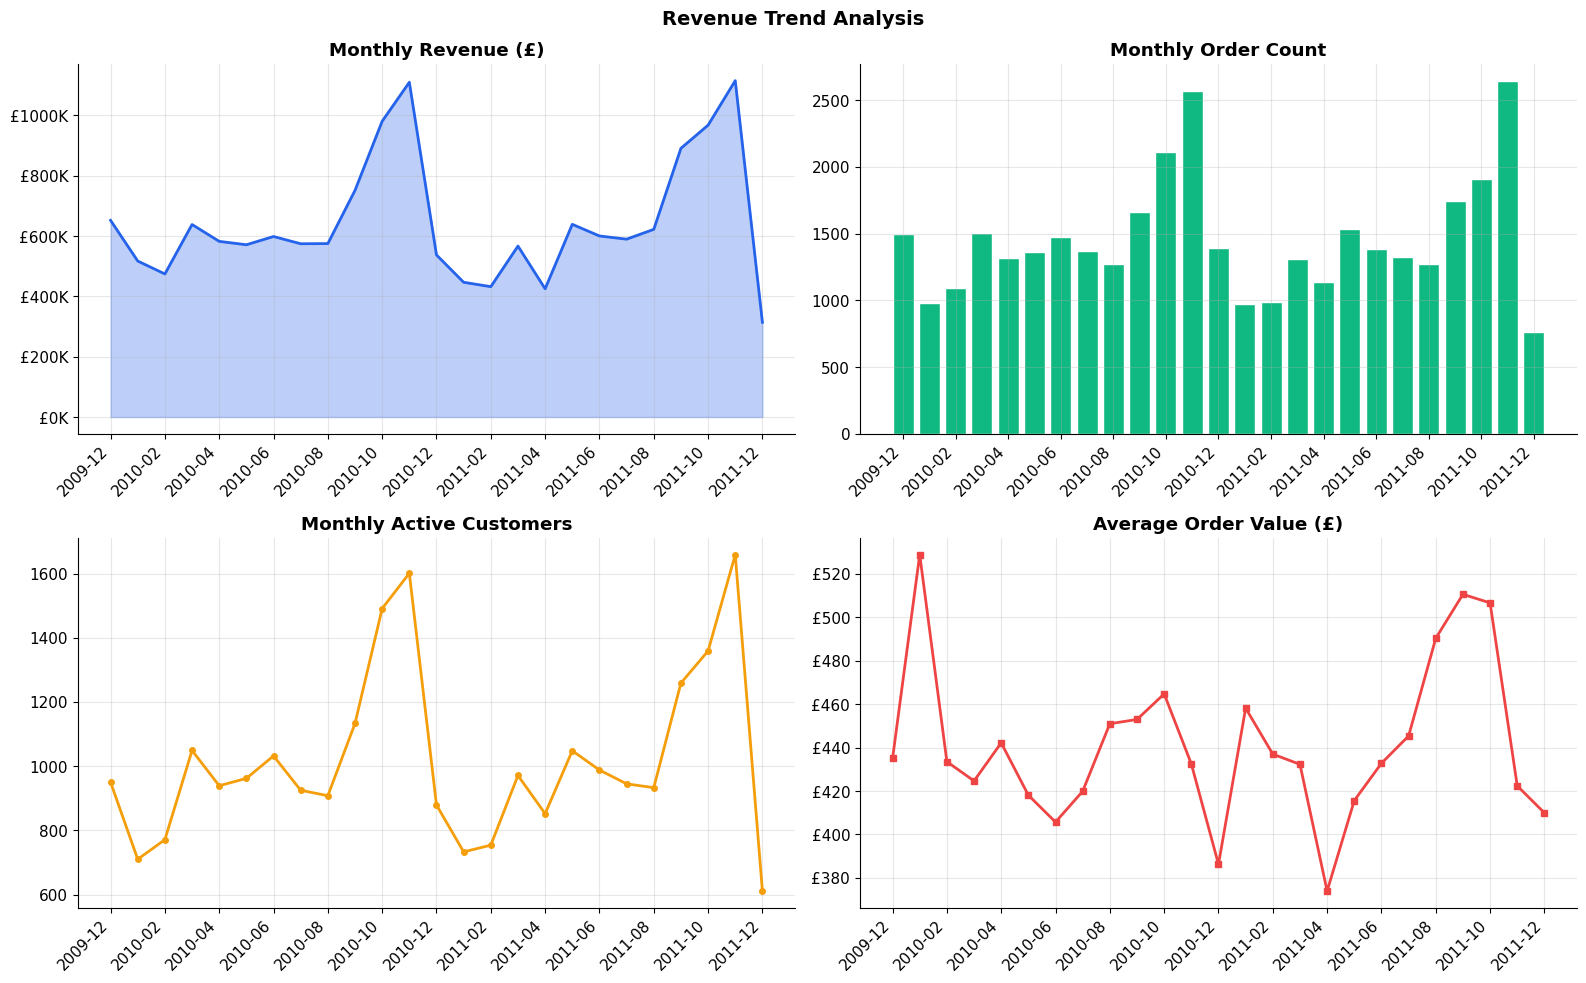

In [57]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Revenue Trend Analysis', fontsize=14, fontweight='bold')

months = range(len(monthly))
labels = monthly['OrderMonth'].astype(str)

# Monthly Revenue
axes[0,0].fill_between(months, monthly['Revenue'], alpha=0.3, color=PALETTE[0])
axes[0,0].plot(months, monthly['Revenue'], color=PALETTE[0], linewidth=2)
axes[0,0].set_title('Monthly Revenue (£)', fontweight='bold')
axes[0,0].set_xticks(months[::2]); axes[0,0].set_xticklabels(labels[::2], rotation=45, ha='right')
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))

# Monthly Orders
axes[0,1].bar(months, monthly['Orders'], color=PALETTE[1], edgecolor='white')
axes[0,1].set_title('Monthly Order Count', fontweight='bold')
axes[0,1].set_xticks(months[::2]); axes[0,1].set_xticklabels(labels[::2], rotation=45, ha='right')

# Active Customers
axes[1,0].plot(months, monthly['Customers'], color=PALETTE[2], linewidth=2, marker='o', markersize=4)
axes[1,0].set_title('Monthly Active Customers', fontweight='bold')
axes[1,0].set_xticks(months[::2]); axes[1,0].set_xticklabels(labels[::2], rotation=45, ha='right')

# Average Order Value
axes[1,1].plot(months, monthly['AOV'], color=PALETTE[3], linewidth=2, marker='s', markersize=4)
axes[1,1].set_title('Average Order Value (£)', fontweight='bold')
axes[1,1].set_xticks(months[::2]); axes[1,1].set_xticklabels(labels[::2], rotation=45, ha='right')
axes[1,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:.0f}'))

plt.tight_layout()
plt.savefig('revenue_trends.png', dpi=150, bbox_inches='tight')
plt.show()

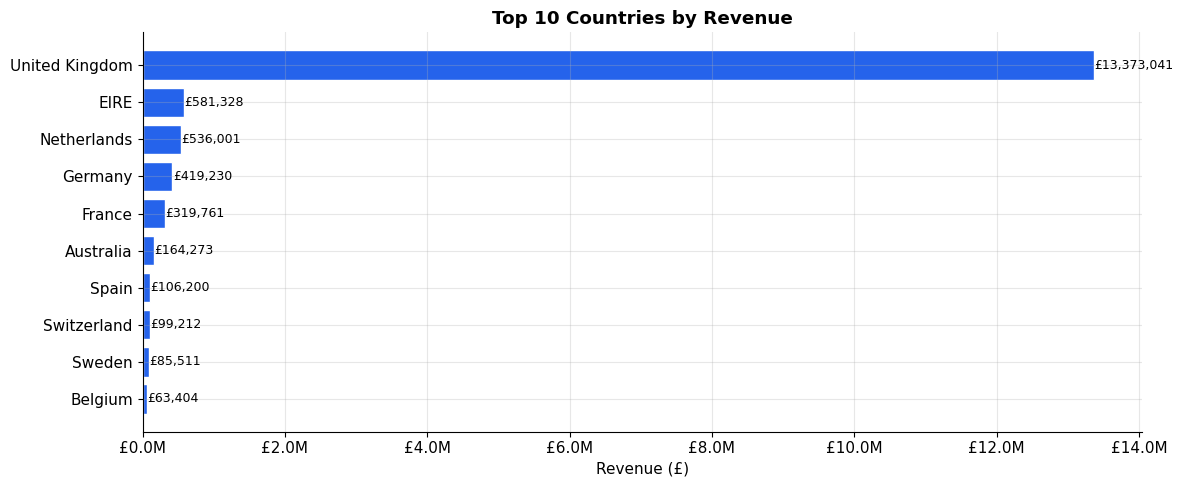

In [58]:
# Revenue by country (Top 10)
country_rev = (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(country_rev.index[::-1], country_rev.values[::-1],
               color=PALETTE[0], edgecolor='white')
ax.set_title('Top 10 Countries by Revenue', fontweight='bold')
ax.set_xlabel('Revenue (£)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
for bar, val in zip(bars, country_rev.values[::-1]):
    ax.text(val + 5000, bar.get_y() + bar.get_height()/2,
            f'£{val:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('revenue_by_country.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Customer Segmentation Analysis

**Business Question:** Which customers drive the most revenue? What does the distribution look like?

In [59]:
# Customer-level aggregation 
customer = (
    df.groupby('CustomerID')
    .agg(
        TotalRevenue  = ('Revenue', 'sum'),
        TotalOrders   = ('Invoice', 'nunique'),
        TotalItems    = ('Quantity', 'sum'),
        AvgOrderValue = ('OrderTotal', 'mean'),
        FirstPurchase = ('InvoiceDate', 'min'),
        LastPurchase  = ('InvoiceDate', 'max'),
        Country       = ('Country', 'first')
    )
    .reset_index()
)

customer['Recency']  = (REFERENCE_DATE - customer['LastPurchase']).dt.days
customer['Tenure']   = (customer['LastPurchase'] - customer['FirstPurchase']).dt.days
customer['CLV_proxy'] = customer['TotalRevenue']   # Can be extended with predicted CLV

print(f'Total customers: {len(customer):,}')
customer.describe()

Total customers: 5,840


,CustomerID,TotalRevenue,TotalOrders,TotalItems,AvgOrderValue,FirstPurchase,LastPurchase,Recency,Tenure,CLV_proxy
count,"5,840.00","5,840.00","5,840.00","5,840.00","5,840.00",5840,5840,"5,840.00","5,840.00","5,840.00"
mean,"15,318.23","2,769.02",6.27,"1,584.74",414.36,2010-08-22 18:05:53.208903936,2011-05-23 12:34:18.482876672,199.49,273.40,"2,769.02"
min,"12,346.00",2.90,1.00,1.00,2.90,2009-12-01 07:45:00,2009-12-01 10:49:00,0.00,0.00,2.90
25%,"13,834.75",338.88,1.00,188.00,194.63,2010-02-10 04:25:30,2010-11-25 13:48:15,25.00,0.00,338.88
50%,"15,319.50",852.18,3.00,479.00,310.83,2010-06-28 11:46:30,2011-09-05 14:45:00,94.00,221.00,852.18
75%,"16,801.25","2,211.19",7.00,"1,335.00",474.02,2011-02-01 12:30:00,2011-11-14 12:45:30,378.00,511.00,"2,211.19"
max,"18,287.00","522,432.52",376.00,"353,631.00","13,080.07",2011-12-09 12:16:00,2011-12-09 12:50:00,738.00,738.00,"522,432.52"
std,"1,715.46","13,126.64",12.77,"7,422.83",480.50,NaN,NaN,208.76,258.52,"13,126.64"


Top 10% of customers contribute: 62.2% of revenue
Top 20% of customers contribute: 76.1% of revenue


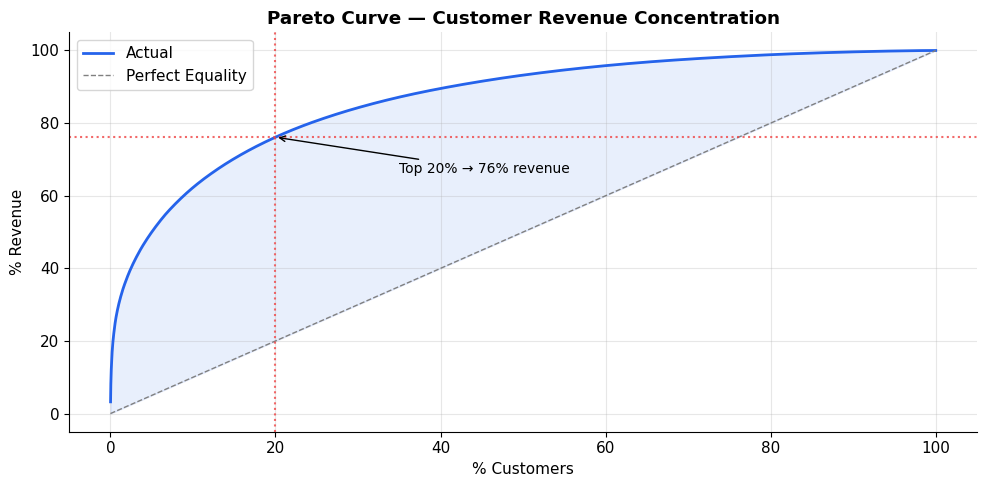

In [60]:
# Pareto analysis (80/20 rule) 
customer_sorted = customer.sort_values('TotalRevenue', ascending=False).reset_index(drop=True)
customer_sorted['CumulativeRevenue'] = customer_sorted['TotalRevenue'].cumsum()
customer_sorted['RevenuePct']        = customer_sorted['CumulativeRevenue'] / customer_sorted['TotalRevenue'].sum() * 100
customer_sorted['CustomerPct']       = (customer_sorted.index + 1) / len(customer_sorted) * 100

top10_pct  = customer_sorted.loc[customer_sorted['CustomerPct'] <= 10, 'RevenuePct'].max()
top20_pct  = customer_sorted.loc[customer_sorted['CustomerPct'] <= 20, 'RevenuePct'].max()

print(f'Top 10% of customers contribute: {top10_pct:.1f}% of revenue')
print(f'Top 20% of customers contribute: {top20_pct:.1f}% of revenue')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(customer_sorted['CustomerPct'], customer_sorted['RevenuePct'],
        color=PALETTE[0], linewidth=2, label='Actual')
ax.plot([0, 100], [0, 100], '--', color='grey', linewidth=1, label='Perfect Equality')
ax.axvline(20, color=PALETTE[3], linestyle=':', alpha=0.8)
ax.axhline(top20_pct, color=PALETTE[3], linestyle=':', alpha=0.8)
ax.fill_between(customer_sorted['CustomerPct'], customer_sorted['RevenuePct'],
                customer_sorted['CustomerPct'], alpha=0.1, color=PALETTE[0])
ax.annotate(f'Top 20% → {top20_pct:.0f}% revenue',
            xy=(20, top20_pct), xytext=(35, top20_pct - 10),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=10)
ax.set_xlabel('% Customers')
ax.set_ylabel('% Revenue')
ax.set_title('Pareto Curve — Customer Revenue Concentration', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('pareto_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [61]:
# Top 10 customers 
print('=== TOP 10 CUSTOMERS BY REVENUE ===')
print(
    customer_sorted[['CustomerID', 'TotalRevenue', 'TotalOrders', 'AvgOrderValue', 'Recency', 'Country']]
    .head(10)
    .to_string(index=False)
)

=== TOP 10 CUSTOMERS BY REVENUE ===
 CustomerID  TotalRevenue  TotalOrders  AvgOrderValue  Recency        Country
  18,102.00    522,432.52          143       5,526.67        0 United Kingdom
  14,646.00    510,982.08          147       7,636.74        1    Netherlands
  14,156.00    298,296.93          146       3,379.23        9           EIRE
  14,911.00    271,793.09          376       1,049.37        0           EIRE
  13,694.00    191,284.21          139       2,925.57        3 United Kingdom
  17,511.00    172,036.87           60       3,880.85        2 United Kingdom
  17,450.00    144,059.97           50       3,932.10        7 United Kingdom
  12,415.00    140,506.17           26      13,080.07       23      Australia
  16,684.00    137,422.13           53       4,851.25        3 United Kingdom
  15,061.00    121,553.02          124       1,735.90        3 United Kingdom


---
## 4. RFM Analysis & Scoring

**Business Question:** How do we segment customers for targeted marketing?

In [62]:
# Compute RFM metrics 
rfm = (
    df.groupby('CustomerID')
    .agg(
        Recency   = ('InvoiceDate', lambda x: (REFERENCE_DATE - x.max()).days),
        Frequency = ('Invoice', 'nunique'),
        Monetary  = ('Revenue', 'sum')
    )
    .reset_index()
)

print('RFM base metrics:')
print(rfm.describe())

RFM base metrics:
       CustomerID  Recency  Frequency   Monetary
count    5,840.00 5,840.00   5,840.00   5,840.00
mean    15,318.23   199.49       6.27   2,769.02
std      1,715.46   208.76      12.77  13,126.64
min     12,346.00     0.00       1.00       2.90
25%     13,834.75    25.00       1.00     338.88
50%     15,319.50    94.00       3.00     852.18
75%     16,801.25   378.00       7.00   2,211.19
max     18,287.00   738.00     376.00 522,432.52


In [63]:
# Assign RFM scores (1–5 quintiles)
# Recency: lower = better → reverse scoring
rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'),  q=5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Total'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print('RFM scores assigned')
rfm.head(5)

RFM scores assigned


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
0,"12,346.00",528,11,372.86,1,5,2,152,8
1,"12,347.00",1,8,"4,921.53",5,4,5,545,14
2,"12,348.00",74,5,"2,019.40",3,4,4,344,11
3,"12,349.00",18,3,"3,678.69",5,3,5,535,13
4,"12,350.00",309,1,334.40,2,1,2,212,5


In [64]:
# Segment mapping 
def rfm_segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    total = r + f + m
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal'
    elif r >= 4 and f <= 2:
        return 'Recent'
    elif r >= 3 and f <= 2 and m >= 3:
        return 'Potential Loyalists'
    elif r == 2 and f >= 2:
        return 'At Risk'
    elif r <= 2 and f >= 3:
        return 'Cant Lose Them'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    elif total <= 5:
        return 'Hibernating'
    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(rfm_segment, axis=1)

seg_summary = rfm.groupby('Segment').agg(
    Customers  = ('CustomerID', 'count'),
    AvgRecency = ('Recency', 'mean'),
    AvgFreq    = ('Frequency', 'mean'),
    TotalRev   = ('Monetary', 'sum')
).sort_values('TotalRev', ascending=False)

seg_summary['Revenue_%'] = (seg_summary['TotalRev'] / seg_summary['TotalRev'].sum() * 100).round(1)
print(seg_summary.to_string())

                     Customers  AvgRecency  AvgFreq      TotalRev  Revenue_%
Segment                                                                     
Champions                 1292       18.86    16.99 11,253,355.70      69.60
Loyal                     1388       69.91     5.39  2,490,548.24      15.40
At Risk                    864      305.43     3.91  1,100,375.05       6.80
Cant Lose Them             276      501.08     4.51    437,208.55       2.70
Lost                      1027      498.34     1.11    246,869.30       1.50
Recent                     446       27.33     1.46    241,268.30       1.50
Needs Attention            318      250.04     1.43    234,674.73       1.50
Potential Loyalists        106      103.73     1.68    125,594.36       0.80
Hibernating                123      218.97     1.00     41,157.22       0.30


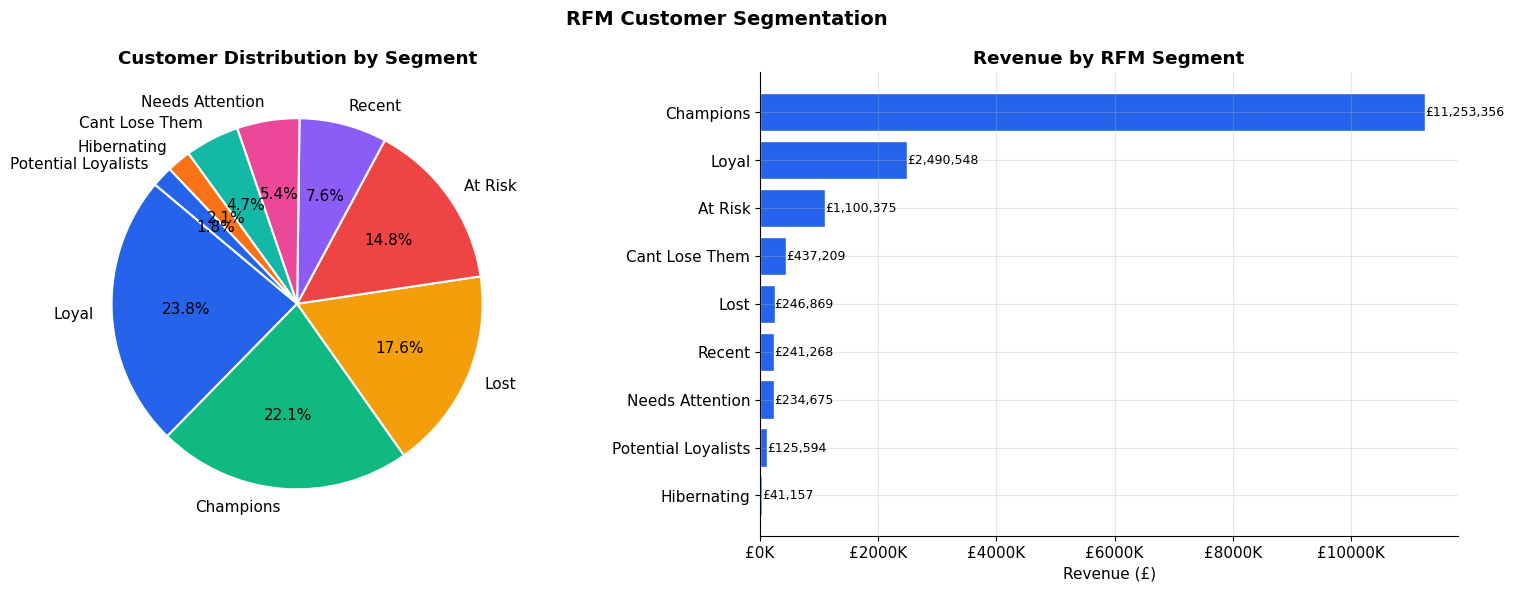

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RFM Customer Segmentation', fontsize=14, fontweight='bold')

# Customer count by segment
seg_count = rfm['Segment'].value_counts()
wedge_colors = PALETTE[:len(seg_count)]
axes[0].pie(seg_count.values, labels=seg_count.index, autopct='%1.1f%%',
            colors=wedge_colors, startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Customer Distribution by Segment', fontweight='bold')

# Revenue by segment
seg_rev = seg_summary['TotalRev'].sort_values()
bars = axes[1].barh(seg_rev.index, seg_rev.values, color=PALETTE[0], edgecolor='white')
axes[1].set_title('Revenue by RFM Segment', fontweight='bold')
axes[1].set_xlabel('Revenue (£)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
for bar, val in zip(bars, seg_rev.values):
    axes[1].text(val + 500, bar.get_y() + bar.get_height()/2,
                f'£{val:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

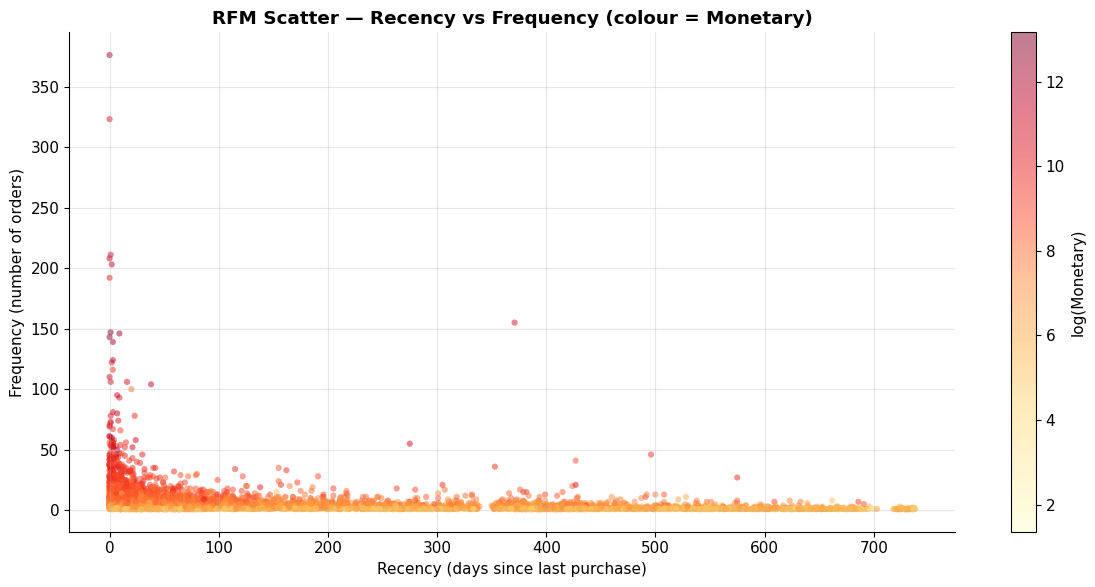

In [66]:
# RFM scatter: Recency vs Frequency, coloured by Monetary 
fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(rfm['Recency'], rfm['Frequency'],
                     c=np.log1p(rfm['Monetary']), cmap='YlOrRd',
                     alpha=0.5, s=20, edgecolors='none')
plt.colorbar(scatter, ax=ax, label='log(Monetary)')
ax.set_xlabel('Recency (days since last purchase)')
ax.set_ylabel('Frequency (number of orders)')
ax.set_title('RFM Scatter — Recency vs Frequency (colour = Monetary)', fontweight='bold')
plt.tight_layout()
plt.savefig('rfm_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [67]:
# Export RFM table 
rfm.to_csv('Data/RFM_Segments.csv', index=False)
print('✅ RFM_Segments.csv exported')

✅ RFM_Segments.csv exported


---
## 5. Cohort Retention Analysis

**Business Question:** How well do we retain customers month over month?

In [68]:
# Build cohort table 
cohort_df = df[['CustomerID', 'InvoiceDate', 'Invoice']].copy()

# First purchase month per customer (their cohort)
cohort_df['CohortMonth'] = cohort_df.groupby('CustomerID')['InvoiceDate'].transform('min').dt.to_period('M')
cohort_df['OrderMonth']  = cohort_df['InvoiceDate'].dt.to_period('M')

# Month index: 0 = acquisition month, 1 = 1 month later, etc.
cohort_df['CohortIndex'] = (
    cohort_df['OrderMonth'].dt.start_time - cohort_df['CohortMonth'].dt.start_time
).dt.days // 30

# Count unique customers per cohort per month
cohort_counts = (
    cohort_df.groupby(['CohortMonth', 'CohortIndex'])
    ['CustomerID'].nunique()
    .reset_index()
)

# Pivot to matrix
cohort_matrix = cohort_counts.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')

# Retention rates: divide each row by cohort size (column 0)
cohort_size   = cohort_matrix.iloc[:, 0]
retention_matrix = cohort_matrix.divide(cohort_size, axis=0).round(3) * 100

print(f'Cohort matrix shape: {cohort_matrix.shape}')
print('Showing first 6 cohorts × 6 months:')
print(retention_matrix.iloc[:6, :7].to_string())

Cohort matrix shape: (25, 25)
Showing first 6 cohorts × 6 months:
CohortIndex      0     1     2     3     4     5     6
CohortMonth                                           
2009-12     100.00 35.30 33.50 42.50 38.20 35.90 37.70
2010-01     100.00 42.10   NaN 31.20 26.70 30.10 26.40
2010-02     100.00 22.50 28.90   NaN 24.60 20.10 19.00
2010-03     100.00 19.10 23.20 24.10 23.20 20.50 25.10
2010-04     100.00 19.20 19.60 16.50 18.60 22.70 27.80
2010-05     100.00 15.70 16.90 17.60 17.60 25.50 21.20


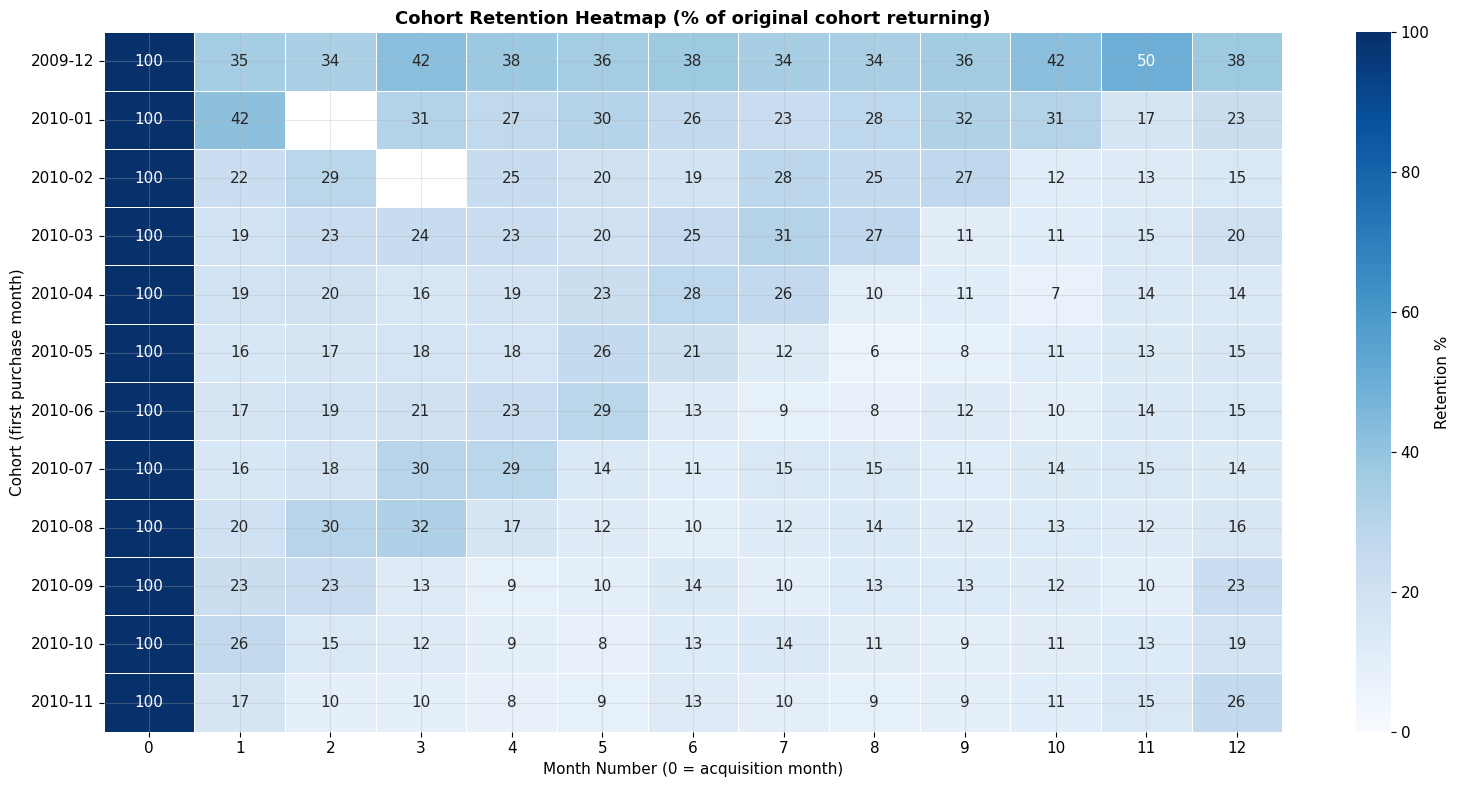

In [69]:
# Cohort heatmap
# Limit to first 12 cohorts and 12 months for readability
plot_matrix = retention_matrix.iloc[:12, :13]

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(
    plot_matrix,
    annot=True, fmt='.0f', linewidths=0.5,
    cmap='Blues', vmin=0, vmax=100,
    ax=ax, cbar_kws={'label': 'Retention %'}
)
ax.set_title('Cohort Retention Heatmap (% of original cohort returning)', fontweight='bold', fontsize=13)
ax.set_xlabel('Month Number (0 = acquisition month)')
ax.set_ylabel('Cohort (first purchase month)')
ax.set_yticklabels([str(c) for c in plot_matrix.index], rotation=0)
plt.tight_layout()
plt.savefig('cohort_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

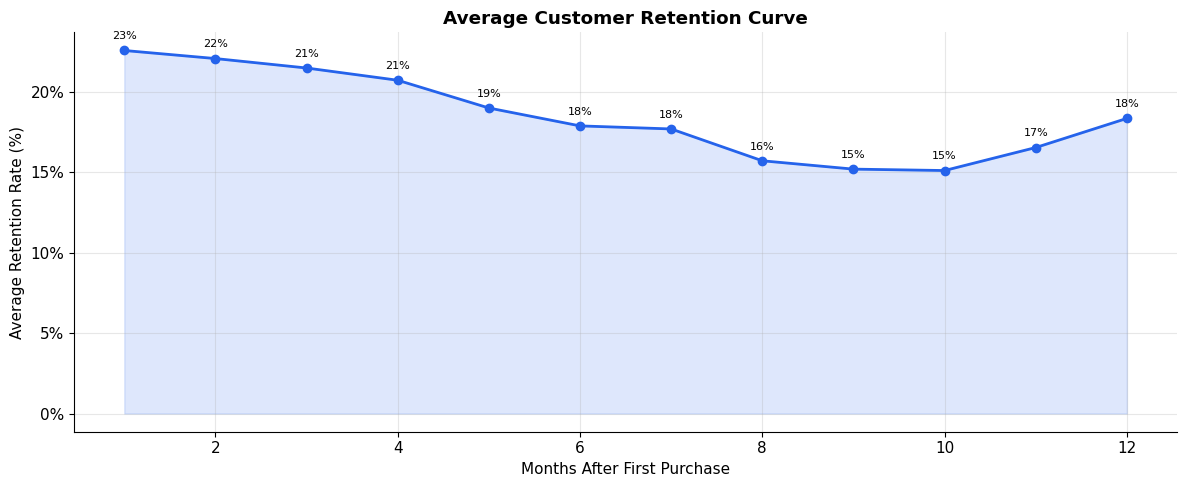


Average Retention by Month:
 Month  Avg_Retention_%
     1            22.56
     2            22.06
     3            21.47
     4            20.71
     5            18.98
     6            17.87
     7            17.68
     8            15.71
     9            15.19
    10            15.10
    11            16.53
    12            18.34


In [70]:
# Average retention by month number 
avg_retention = retention_matrix.iloc[:, 1:13].mean().reset_index()
avg_retention.columns = ['Month', 'Avg_Retention_%']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(avg_retention['Month'], avg_retention['Avg_Retention_%'],
        marker='o', color=PALETTE[0], linewidth=2)
ax.fill_between(avg_retention['Month'], avg_retention['Avg_Retention_%'], alpha=0.15, color=PALETTE[0])
ax.set_xlabel('Months After First Purchase')
ax.set_ylabel('Average Retention Rate (%)')
ax.set_title('Average Customer Retention Curve', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

for _, row in avg_retention.iterrows():
    ax.annotate(f"{row['Avg_Retention_%']:.0f}%",
                xy=(row['Month'], row['Avg_Retention_%']),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('retention_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nAverage Retention by Month:')
print(avg_retention.to_string(index=False))

---
## 6. Churn Pattern Analysis

**Business Question:** What inactivity period predicts churn? Which segments are most at risk?

In [71]:
# Define churn threshold using average inter-purchase gap 

# For each customer, compute average gap between consecutive orders

order_dates = df.groupby(['CustomerID', 'Invoice'])['InvoiceDate'].min().reset_index()
order_dates = order_dates.sort_values(['CustomerID', 'InvoiceDate'])
order_dates['PrevDate'] = order_dates.groupby('CustomerID')['InvoiceDate'].shift(1)
order_dates['Gap_days'] = (order_dates['InvoiceDate'] - order_dates['PrevDate']).dt.days

avg_gap = order_dates['Gap_days'].dropna().mean()
churn_threshold = int(avg_gap * 2)   # 2× average gap = churn signal

print(f'Average inter-purchase gap : {avg_gap:.0f} days')
print(f'Churn threshold (2× gap)   : {churn_threshold} days')

Average inter-purchase gap : 52 days
Churn threshold (2× gap)   : 103 days


In [72]:
# Classify customers: Active / At Risk / Churned 
customer['Status'] = pd.cut(
    customer['Recency'],
    bins=[-1, 30, churn_threshold, 365, np.inf],
    labels=['Active (≤30d)', 'At Risk', 'Inactive', 'Churned (>1yr)']
)

status_summary = (
    customer.groupby('Status', observed=False)
    .agg(Customers=('CustomerID', 'count'), TotalRevenue=('TotalRevenue', 'sum'))
)
status_summary['Revenue_%'] = (status_summary['TotalRevenue'] / status_summary['TotalRevenue'].sum() * 100).round(1)

print('=== CUSTOMER STATUS SUMMARY ===')
print(status_summary.to_string())

=== CUSTOMER STATUS SUMMARY ===
                Customers  TotalRevenue  Revenue_%
Status                                            
Active (≤30d)        1689 10,446,757.04      64.60
At Risk              1292  2,893,947.46      17.90
Inactive             1281  1,707,346.55      10.60
Churned (>1yr)       1578  1,123,000.40       6.90


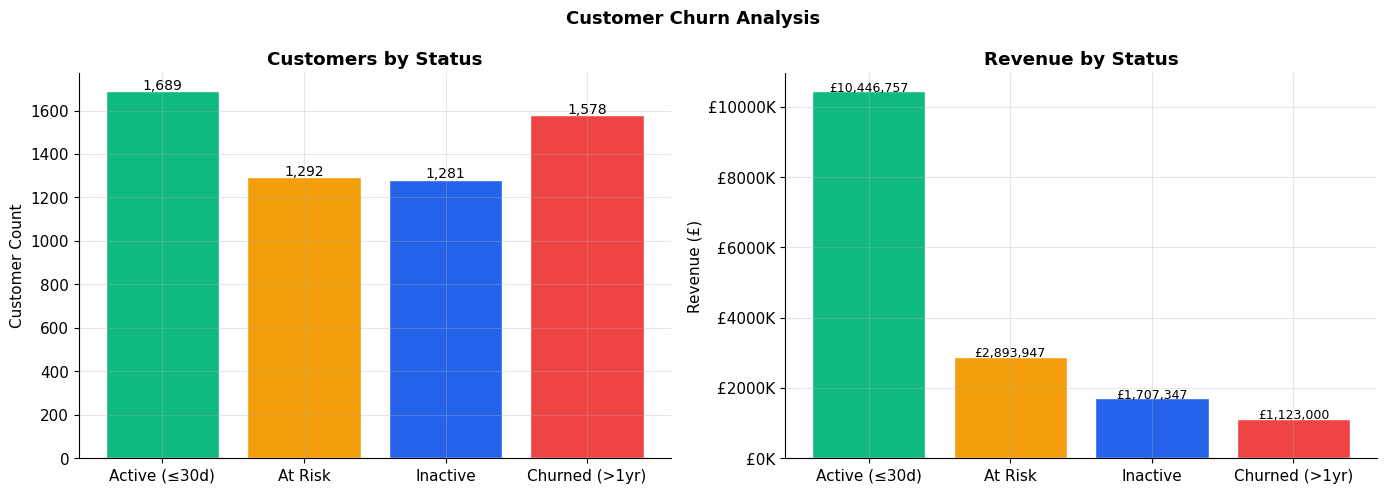

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Customer Churn Analysis', fontsize=13, fontweight='bold')

colors_status = [PALETTE[1], PALETTE[2], PALETTE[0], PALETTE[3]]

# Count
axes[0].bar(status_summary.index, status_summary['Customers'],
            color=colors_status, edgecolor='white')
axes[0].set_title('Customers by Status', fontweight='bold')
axes[0].set_ylabel('Customer Count')
for i, v in enumerate(status_summary['Customers']):
    axes[0].text(i, v + 10, f'{v:,}', ha='center', fontsize=10)

# Revenue
axes[1].bar(status_summary.index, status_summary['TotalRevenue'],
            color=colors_status, edgecolor='white')
axes[1].set_title('Revenue by Status', fontweight='bold')
axes[1].set_ylabel('Revenue (£)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
for i, v in enumerate(status_summary['TotalRevenue']):
    axes[1].text(i, v + 1000, f'£{v:,.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('churn_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

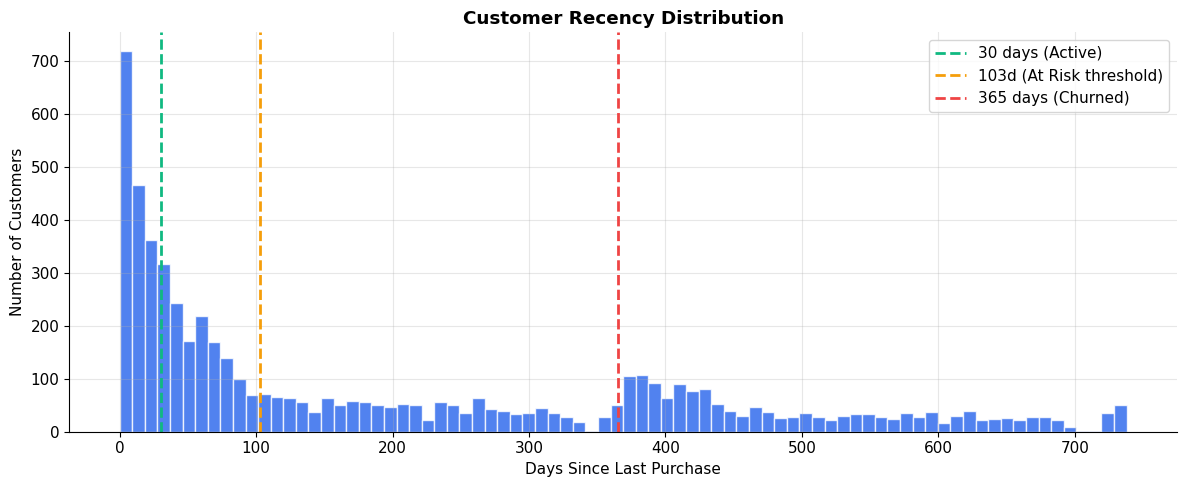

In [74]:
#  Recency distribution (where is the 'cliff'?) 
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(customer['Recency'], bins=80, color=PALETTE[0], edgecolor='white', alpha=0.8)
ax.axvline(30,               color=PALETTE[1], linestyle='--', linewidth=2, label='30 days (Active)')
ax.axvline(churn_threshold,  color=PALETTE[2], linestyle='--', linewidth=2, label=f'{churn_threshold}d (At Risk threshold)')
ax.axvline(365,              color=PALETTE[3], linestyle='--', linewidth=2, label='365 days (Churned)')
ax.set_xlabel('Days Since Last Purchase')
ax.set_ylabel('Number of Customers')
ax.set_title('Customer Recency Distribution', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('recency_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Customer Behavior Analysis

**Business Questions:**
- Do higher spenders return more often?
- What drives repeat purchases?
- When do customers buy (day / hour)?

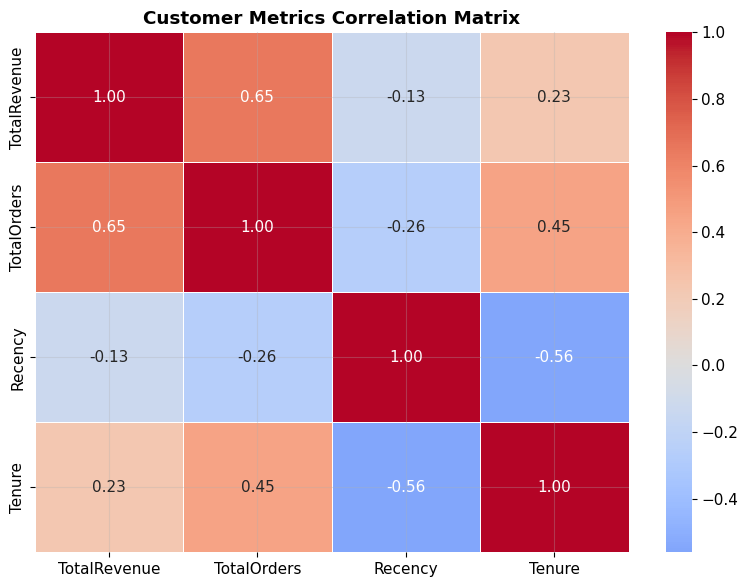

In [75]:
# Spend vs. Frequency correlation 
corr = customer[['TotalRevenue', 'TotalOrders', 'Recency', 'Tenure']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Customer Metrics Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

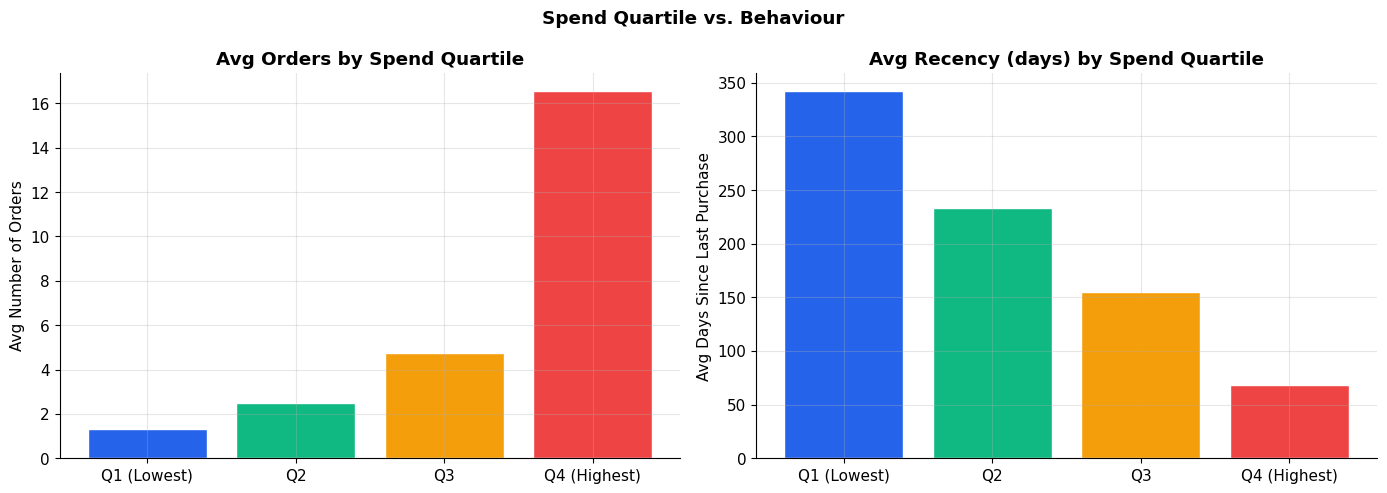

SpendQuartile  AvgOrders  AvgRecency  CustomerCnt
  Q1 (Lowest)       1.30      342.16         1460
           Q2       2.48      232.98         1460
           Q3       4.74      154.66         1460
 Q4 (Highest)      16.54       68.16         1460


In [76]:
# Do higher spenders return more? 
# Bin customers into spend quartiles
customer['SpendQuartile'] = pd.qcut(customer['TotalRevenue'], q=4,
                                    labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)'])

spend_vs_freq = customer.groupby('SpendQuartile', observed=False).agg(
    AvgOrders   = ('TotalOrders', 'mean'),
    AvgRecency  = ('Recency', 'mean'),
    CustomerCnt = ('CustomerID', 'count')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Spend Quartile vs. Behaviour', fontweight='bold')

axes[0].bar(spend_vs_freq['SpendQuartile'], spend_vs_freq['AvgOrders'],
            color=PALETTE, edgecolor='white')
axes[0].set_title('Avg Orders by Spend Quartile', fontweight='bold')
axes[0].set_ylabel('Avg Number of Orders')

axes[1].bar(spend_vs_freq['SpendQuartile'], spend_vs_freq['AvgRecency'],
            color=PALETTE, edgecolor='white')
axes[1].set_title('Avg Recency (days) by Spend Quartile', fontweight='bold')
axes[1].set_ylabel('Avg Days Since Last Purchase')

plt.tight_layout()
plt.savefig('spend_vs_behavior.png', dpi=150, bbox_inches='tight')
plt.show()

print(spend_vs_freq.to_string(index=False))

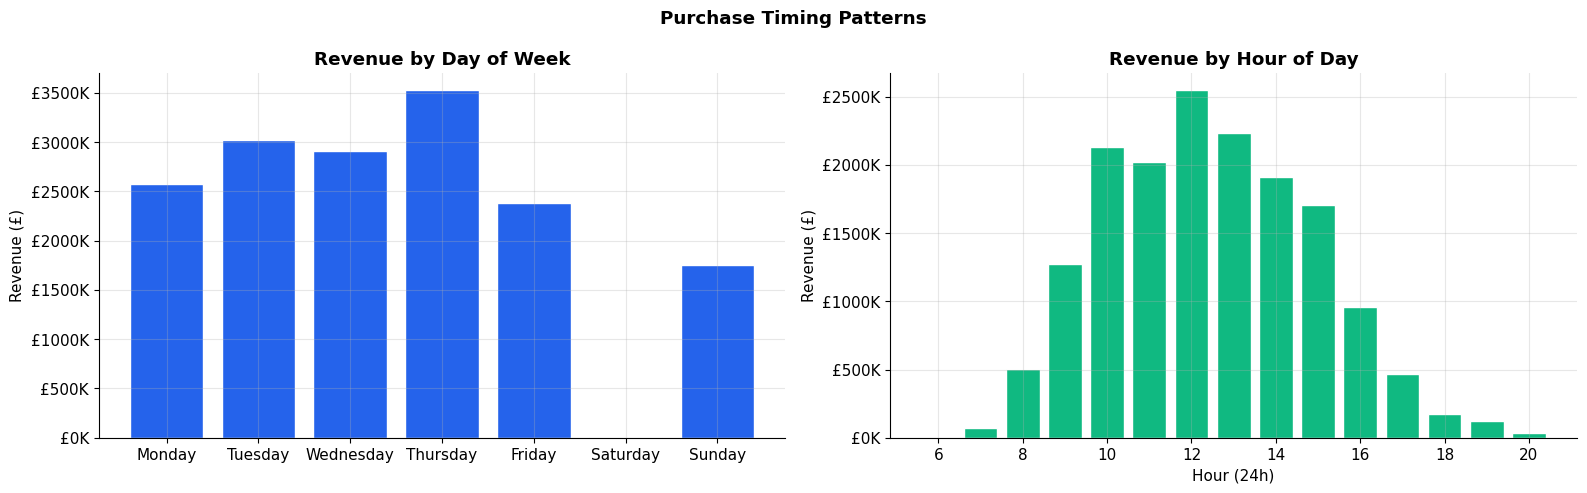

In [77]:
# Purchasing patterns: Day of week & Hour 
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_rev = df.groupby('OrderDayOfWeek')['Revenue'].sum().reindex(day_order)
hour_rev = df.groupby('OrderHour')['Revenue'].sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Purchase Timing Patterns', fontweight='bold')

axes[0].bar(day_rev.index, day_rev.values, color=PALETTE[0], edgecolor='white')
axes[0].set_title('Revenue by Day of Week', fontweight='bold')
axes[0].set_ylabel('Revenue (£)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))

axes[1].bar(hour_rev.index, hour_rev.values, color=PALETTE[1], edgecolor='white')
axes[1].set_title('Revenue by Hour of Day', fontweight='bold')
axes[1].set_ylabel('Revenue (£)')
axes[1].set_xlabel('Hour (24h)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))

plt.tight_layout()
plt.savefig('purchase_timing.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Revenue Leakage Quantification

**Business Question:** How much revenue are we losing? Who are the high-value inactive customers?

In [79]:
# Identify high-value inactive / churned customers
INACTIVITY_THRESHOLD = churn_threshold   # days

inactive = customer[customer['Recency'] > INACTIVITY_THRESHOLD].copy()
high_value_inactive = inactive[
    inactive['TotalRevenue'] >= inactive['TotalRevenue'].quantile(0.75)
].sort_values('TotalRevenue', ascending=False)

print(f'Inactive customers (>{INACTIVITY_THRESHOLD}d): {len(inactive):,}')
print(f'High-value inactive: {len(high_value_inactive):,}')
print(f'\nRevenue from now-inactive customers: £{inactive["TotalRevenue"].sum():,.2f}')
print(f'Revenue at risk (high-value inactive): £{high_value_inactive["TotalRevenue"].sum():,.2f}')

Inactive customers (>103d): 2,859
High-value inactive: 715

Revenue from now-inactive customers: £2,830,346.96
Revenue at risk (high-value inactive): £1,991,196.61


In [80]:
#  Estimated annual revenue leakage 
# Approach: avg monthly revenue per customer × churned customer count × 12
total_months = (df['InvoiceDate'].max() - df['InvoiceDate'].min()).days / 30
avg_monthly_rev_per_customer = customer['TotalRevenue'].sum() / (customer['CustomerID'].nunique() * total_months)
churned_customers = len(customer[customer['Recency'] > 365])
estimated_annual_leakage = avg_monthly_rev_per_customer * churned_customers * 12

total_revenue = customer['TotalRevenue'].sum()

print('='*55)
print('  REVENUE LEAKAGE SUMMARY')
print('='*55)
print(f'  Total Customer Revenue       : £{total_revenue:>12,.2f}')
print(f'  Inactive Customers (>{INACTIVITY_THRESHOLD}d)   : {len(inactive):>12,}')
print(f'  Revenue from Inactive         : £{inactive["TotalRevenue"].sum():>12,.2f}')
print(f'  Churned Customers (>365d)     : {churned_customers:>12,}')
print(f'  Est. Annual Revenue Leakage   : £{estimated_annual_leakage:>12,.2f}')
print(f'  Leakage as % of Total Rev     : {estimated_annual_leakage/total_revenue*100:>11.1f}%')
print('='*55)

  REVENUE LEAKAGE SUMMARY
  Total Customer Revenue       : £16,171,051.45
  Inactive Customers (>103d)   :        2,859
  Revenue from Inactive         : £2,830,346.96
  Churned Customers (>365d)     :        1,578
  Est. Annual Revenue Leakage   : £2,131,466.69
  Leakage as % of Total Rev     :        13.2%


In [81]:
# Top 15 high-value inactive customers for re-engagement
print('=== TOP 15 HIGH-VALUE INACTIVE CUSTOMERS (Re-engagement Targets) ===')
print(
    high_value_inactive[['CustomerID', 'TotalRevenue', 'TotalOrders',
                          'AvgOrderValue', 'Recency', 'Country']]
    .head(15)
    .to_string(index=False)
)

=== TOP 15 HIGH-VALUE INACTIVE CUSTOMERS (Re-engagement Targets) ===
 CustomerID  TotalRevenue  TotalOrders  AvgOrderValue  Recency        Country
  13,093.00     54,144.25           55       1,207.91      275 United Kingdom
  17,850.00     51,208.87          155         426.15      371 United Kingdom
  16,754.00     40,795.59           21       3,355.54      427 United Kingdom
  13,802.00     26,259.11           19       1,583.27      138 United Kingdom
  12,482.00     21,423.32           27       1,123.02      575         Sweden
  15,808.00     17,180.25           21         895.40      305 United Kingdom
  16,553.00     16,584.01           33         549.47      162 United Kingdom
  12,980.00     16,245.78           21         835.15      157 United Kingdom
  13,564.00     15,818.33           36         684.63      353 United Kingdom
  15,768.00     15,058.89           34         536.63      115 United Kingdom
  17,448.00     14,523.67           46         389.95      496 United Kin

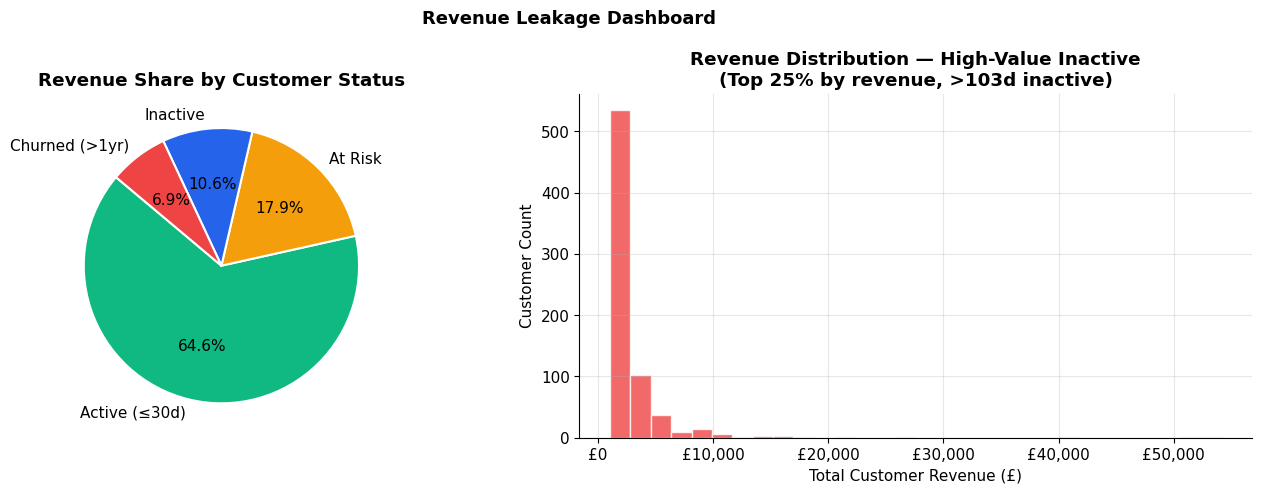

In [82]:
#  Revenue leakage visualisation 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Revenue Leakage Dashboard', fontsize=13, fontweight='bold')

# Revenue split: active vs at-risk vs inactive
status_groups = customer.groupby('Status', observed=False)['TotalRevenue'].sum()
axes[0].pie(status_groups.values, labels=status_groups.index,
            autopct='%1.1f%%', colors=colors_status, startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Revenue Share by Customer Status', fontweight='bold')

# High-value inactive — revenue distribution
axes[1].hist(high_value_inactive['TotalRevenue'], bins=30,
             color=PALETTE[3], edgecolor='white', alpha=0.8)
axes[1].set_title(f'Revenue Distribution — High-Value Inactive\n(Top 25% by revenue, >{INACTIVITY_THRESHOLD}d inactive)',
                  fontweight='bold')
axes[1].set_xlabel('Total Customer Revenue (£)')
axes[1].set_ylabel('Customer Count')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

plt.tight_layout()
plt.savefig('revenue_leakage.png', dpi=150, bbox_inches='tight')
plt.show()

In [84]:
# Export all derived tables 
customer.to_csv('Data/Customer_Segments.csv', index=False)
rfm.to_csv('Data/RFM_Segments.csv', index=False)
high_value_inactive.to_csv('Data/High_Value_Inactive.csv', index=False)
retention_matrix.to_csv('Data/Cohort_Retention.csv')

print('✅ All tables exported:')
print('   Customer_Segments.csv')
print('   RFM_Segments.csv')
print('   High_Value_Inactive.csv')
print('   Cohort_Retention.csv')

✅ All tables exported:
   Customer_Segments.csv
   RFM_Segments.csv
   High_Value_Inactive.csv
   Cohort_Retention.csv


---
## 9. Key Findings Summary

In [86]:
# ── Auto-generate findings ───────────────────────────────────────────────────
total_rev      = customer['TotalRevenue'].sum()
total_cust     = len(customer)
champions_row  = seg_summary.loc['Champions'] if 'Champions' in seg_summary.index else None
churn_rate     = len(customer[customer['Recency'] > churn_threshold]) / total_cust * 100
repeat_pct     = len(customer[customer['TotalOrders'] > 1]) / total_cust * 100
m1_retention   = avg_retention[avg_retention['Month'] == 1]['Avg_Retention_%'].values
m3_retention   = avg_retention[avg_retention['Month'] == 3]['Avg_Retention_%'].values

print('='*65)
print('  KEY FINDINGS — Customer Retention & Revenue Leakage')
print('='*65)
print(f'\n📊 REVENUE')
print(f'  • Total revenue: £{total_rev:,.2f}')
print(f'  • Top 20% of customers drive {top20_pct:.0f}% of revenue')
print(f'  • Estimated annual leakage: £{estimated_annual_leakage:,.2f}')

print(f'\n👥 CUSTOMERS ({total_cust:,} total)')
print(f'  • Repeat purchase rate: {repeat_pct:.1f}%')
print(f'  • Churn rate (>{churn_threshold}d inactive): {churn_rate:.1f}%')
print(f'  • High-value inactive: {len(high_value_inactive):,} customers')

if m1_retention.size > 0:
    print(f'\n🔄 RETENTION')
    print(f'  • Month 1 retention: {m1_retention[0]:.0f}%')
    if m3_retention.size > 0:
        print(f'  • Month 3 retention: {m3_retention[0]:.0f}%')

print(f'\n🎯 SEGMENTS')
for seg, row in seg_summary.head(3).iterrows():
    print(f'  • {seg}: {int(row["Customers"]):,} customers → £{row["TotalRev"]:,.0f} revenue ({row["Revenue_%"]:.1f}%)')

print('='*65)


  KEY FINDINGS — Customer Retention & Revenue Leakage

📊 REVENUE
  • Total revenue: £16,171,051.45
  • Top 20% of customers drive 76% of revenue
  • Estimated annual leakage: £2,131,466.69

👥 CUSTOMERS (5,840 total)
  • Repeat purchase rate: 72.3%
  • Churn rate (>103d inactive): 49.0%
  • High-value inactive: 715 customers

🔄 RETENTION
  • Month 1 retention: 23%
  • Month 3 retention: 21%

🎯 SEGMENTS
  • Champions: 1,292 customers → £11,253,356 revenue (69.6%)
  • Loyal: 1,388 customers → £2,490,548 revenue (15.4%)
  • At Risk: 864 customers → £1,100,375 revenue (6.8%)
